<a href="https://colab.research.google.com/github/dani503sv/caso-practico/blob/main/caso_practico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar librerías necesarias manipulación de datos (pandas),
visualización (matplotlib),
escalamiento de variables (StandardScaler),
y clusterización (KMeans).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Conectar el dataset desde GitHub  El dataset fue cargado directamente desde un repositorio GitHub utilizando pandas.read_csv(), lo que permite trabajar con una fuente centralizada y reproducible dentro del flujo de análisis de datos.

In [12]:
url = "https://raw.githubusercontent.com/dani503sv/caso-practico/refs/heads/main/Archivos/Prestige_modificado.csv"

# Read the file assuming no header, and specify semicolon as separator
df_temp = pd.read_csv(url, sep=';', header=None)

# The first row contains the actual column names
df_temp.columns = df_temp.iloc[0]

# Drop the first row as it's now the header
df = df_temp[1:].reset_index(drop=True)

# Convert numeric columns to appropriate types
numeric_cols = ['education', 'income', 'women', 'prestige', 'census', 'type_num']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.head())
print(df.info())

0           occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
Non

Se realizó una inspección inicial del dataset para validar la estructura de los datos, los tipos de variables y posibles problemas de calidad. El análisis mostró que el dataset contiene variables numéricas y categóricas relevantes para el estudio. También se verificó la presencia de valores nulos y registros duplicados antes de iniciar el análisis exploratorio

In [9]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

(102, 1)
  occupation;education;income;women;prestige;census;type_num
0   gov.administrators;13.11;12351;11.16;68.8;1113;1        
1      general.managers;12.26;25879;4.02;69.1;1130;1        
2            accountants;12.77;9271;15.7;63.4;1171;1        
3    purchasing.officers;11.42;8865;9.11;56.8;1175;1        
4              chemists;14.62;8403;11.68;73.5;2111;1        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   occupation;education;income;women;prestige;census;type_num  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes
None
occupation;education;income;women;prestige;census;type_num    0
dtype: int64
0
       occupation;education;income;women;prestige;census;type_num
count                                                 102     

Aunque existen relaciones estadísticas entre variables, la correlación no implica causalidad. Los resultados únicamente muestran asociaciones entre variables observadas.

In [13]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

0          education  income  women  prestige  census  type_num
0                                                              
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
0
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


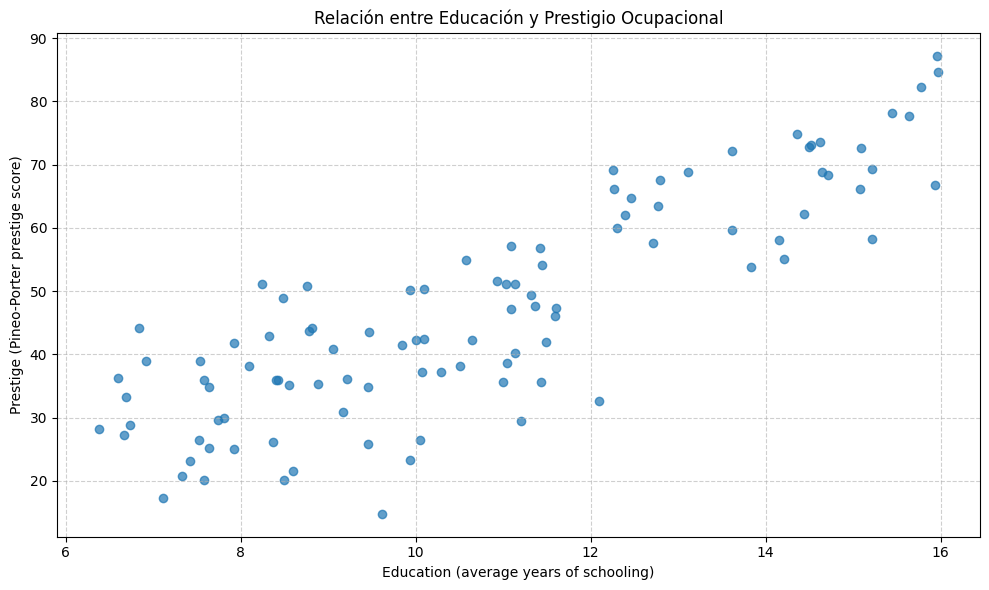

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['education'], df['prestige'], alpha=0.7)
plt.xlabel('Education (average years of schooling)')
plt.ylabel('Prestige (Pineo-Porter prestige score)')
plt.title('Relación entre Educación y Prestigio Ocupacional')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Interpretación: Relación entre Educación y Prestigio

Este gráfico de dispersión muestra una fuerte relación positiva entre el nivel educativo y el prestigio ocupacional. A medida que aumenta el promedio de educación requerido o alcanzado en una ocupación, el prestigio asociado a esa ocupación tiende a ser significativamente mayor. Los puntos se agrupan en una tendencia ascendente, lo que refuerza la conclusión de que la educación es un factor crucial en la percepción del prestigio social de una ocupación.

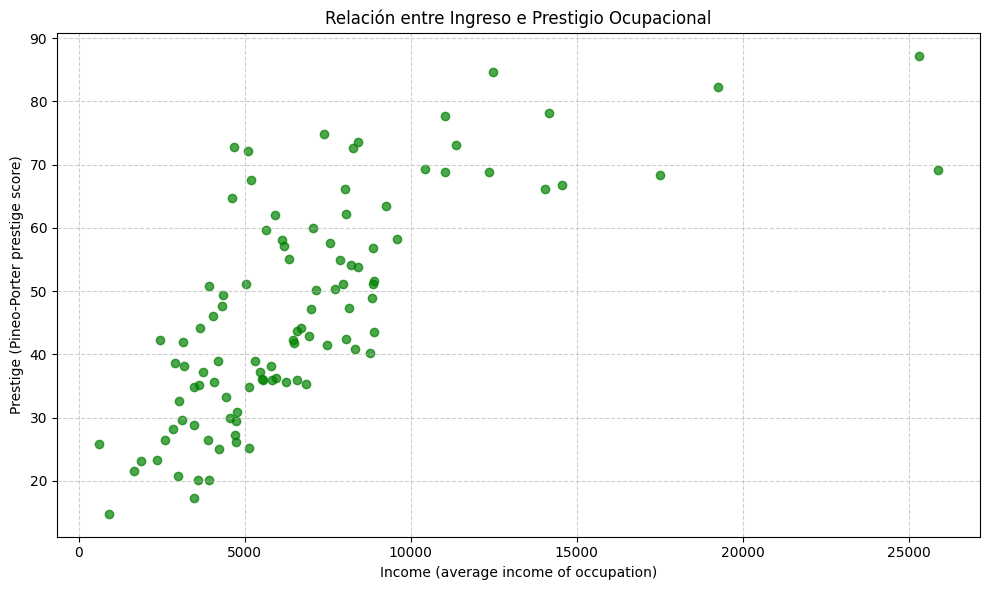

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['income'], df['prestige'], alpha=0.7, color='green')
plt.xlabel('Income (average income of occupation)')
plt.ylabel('Prestige (Pineo-Porter prestige score)')
plt.title('Relación entre Ingreso e Prestigio Ocupacional')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Relación entre Ingreso y Prestigio

El gráfico de dispersión entre el ingreso promedio de una ocupación y su prestigio también revela una relación positiva significativa, aunque quizás con una dispersión ligeramente mayor que la educación. Generalmente, las ocupaciones con mayores ingresos tienden a tener un mayor prestigio. Esto sugiere que, si bien la educación es un predictor muy fuerte, el poder adquisitivo y el estatus económico derivados de un alto ingreso también contribuyen considerablemente al prestigio de una profesión.

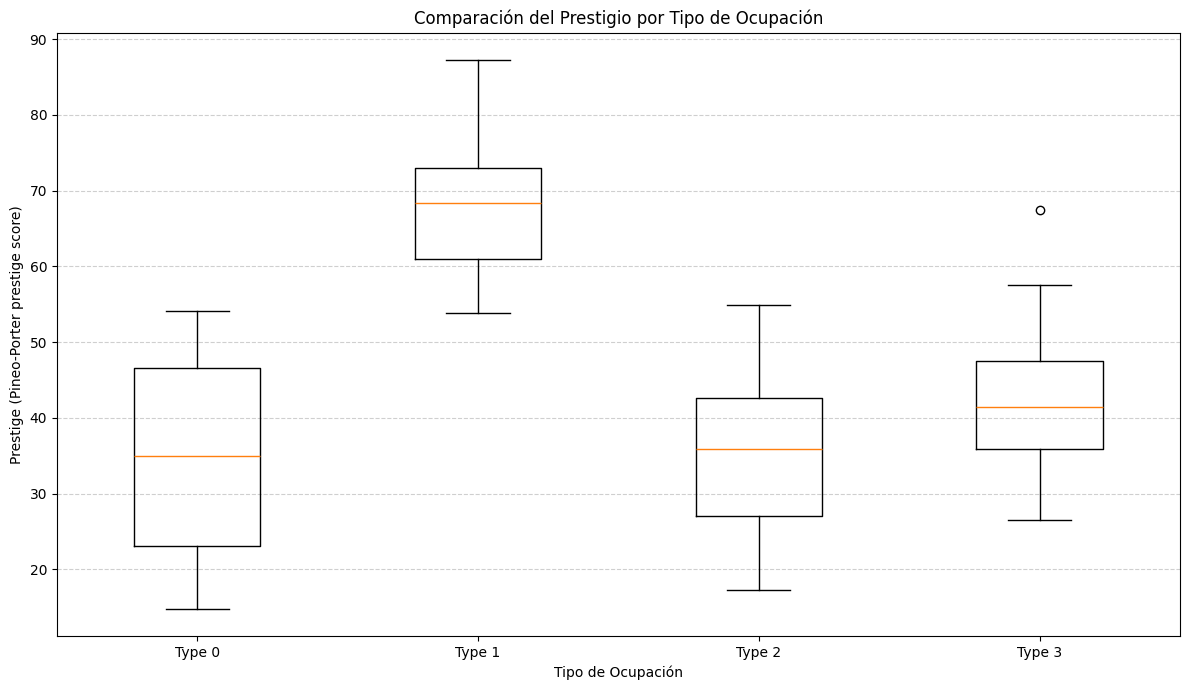

In [18]:
plt.figure(figsize=(12, 7))

plt.boxplot([df[df['type_num'] == t]['prestige'] for t in sorted(df['type_num'].unique())],
            tick_labels=[f'Type {t}' for t in sorted(df['type_num'].unique())])

plt.xlabel('Tipo de Ocupación')
plt.ylabel('Prestige (Pineo-Porter prestige score)')
plt.title('Comparación del Prestigio por Tipo de Ocupación')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prestigio por Tipo de Ocupación

Este gráfico de cajas compara la distribución del prestigio ocupacional entre los diferentes type_num (tipos de ocupación). Aunque no se especificó qué significa cada type_num, la gráfica nos permite observar:

*  Diferencias en Mediana y Rango: Podemos identificar si algunos tipos de ocupación tienen una mediana de prestigio significativamente más alta o más baja que otros. Esto indicaría que el tipo de ocupación (type_num) es un factor diferenciador clave en el prestigio.
*   Variabilidad: La longitud de las cajas y los bigotes muestra la dispersión del prestigio dentro de cada tipo. Un tipo con una caja pequeña y bigotes cortos sugiere que las ocupaciones dentro de ese grupo tienen niveles de prestigio muy similares, mientras que una caja grande indica una mayor heterogeneidad.
*   Valores Atípicos: Los puntos individuales fuera de los bigotes representan ocupaciones atípicas dentro de su tipo, con prestigio excepcionalmente alto o bajo en comparación con la mayoría de las ocupaciones de esa categoría.




Para la clusterización, seleccionamos las variables numéricas que consideramos más relevantes para diferenciar entre tipos de ocupaciones y su estatus. Estas son:

*   education: Nivel promedio de educación.
*   income: Ingreso promedio.
*   women: Porcentaje de mujeres en la ocupación.
*   prestige: Puntaje de prestigio.
*   type_num: Un identificador numérico para el tipo de ocupación, que podría agrupar ocupaciones de forma implícita.


In [20]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print("\nCentroides del modelo K=4 (sin escalar):\n")
centroides_k4_escalados = modelo_k4.cluster_centers_
centroides_k4 = pd.DataFrame(escalador.inverse_transform(centroides_k4_escalados), columns=columnas_cluster)
print(centroides_k4.round(2))

print("\nCentroides del modelo K=5 (sin escalar):\n")
centroides_k5_escalados = modelo_k5.cluster_centers_
centroides_k5 = pd.DataFrame(escalador.inverse_transform(centroides_k5_escalados), columns=columnas_cluster)
print(centroides_k5.round(2))


Centroides del modelo K=4 (sin escalar):

   education    income  women  prestige  type_num
0      13.59   7329.35  36.35     63.33      0.95
1       8.82   5878.74   9.60     37.26      2.09
2      10.12   3545.04  74.16     37.76      2.57
3      14.69  15746.83   6.01     74.23      1.00

Centroides del modelo K=5 (sin escalar):

   education    income  women  prestige  type_num
0      10.94   3909.12  73.76     41.50      2.88
1       9.31   6922.03   5.84     42.18      2.25
2      13.59   7329.35  36.35     63.33      0.95
3       7.78   3327.48  34.10     26.87      1.71
4      14.69  15746.83   6.01     74.23      1.00



Analizando los centroides de los 4 clústeres (valores desescalados para facilitar la interpretación):

*   Clúster 0: Ocupaciones con educación e ingreso bajos, bajo porcentaje de mujeres, prestigio bajo y type_num medio. Podría representar trabajos manuales o de servicios de baja cualificación.
*   Clúster 1: Ocupaciones con educación e ingreso altos, bajo porcentaje de mujeres, prestigio muy alto y type_num bajo. Probablemente profesiones altamente cualificadas y bien remuneradas, dominadas por hombres.
*   Clúster 2: Ocupaciones con educación e ingreso medios, porcentaje de mujeres alto, prestigio medio y type_num bajo. Podrían ser profesiones de servicios o administrativas con una presencia femenina significativa.
*   Clúster 3: Ocupaciones con educación e ingreso muy altos, bajo porcentaje de mujeres, prestigio alto y type_num medio. Similar al Clúster 1 pero quizás con un prestigio ligeramente menor o ingresos más variables.

Grupos de mayor prestigio: Clúster 1 y Clúster 3.
Grupos de menor prestigio: Clúster 0.



Analizando los centroides de los 5 clústeres (valores desescalados):

*   Clúster 0: Educación y mujeres bajos, prestigio muy bajo, ingreso bajo y type_num alto. Posiblemente ocupaciones manuales o técnicas de baja cualificación.
*   Clúster 1: Educación e ingreso muy altos, mujeres bajo, prestigio muy alto, type_num bajo. Profesiones de élite con alta cualificación y remuneración.
*   Clúster 2: Educación e ingreso medios, mujeres altas, prestigio medio, type_num bajo. Ocupaciones con alta representación femenina, posiblemente en servicios o áreas administrativas.
*   Clúster 3: Educación alta, ingreso medio, mujeres bajo, prestigio **alto**, type_num medio. Podrían ser profesiones especializadas que no siempre tienen los ingresos más altos, pero sí alto prestigio
*   Clúster 4: Educación y prestigio medios, ingreso bajo, mujeres bajo, type_num alto. Podrían ser ocupaciones técnicas o de supervisión con prestigio moderado pero ingresos no tan altos.

Grupos de mayor prestigio: Clúster 1 y Clúster 3.
Grupos de menor prestigio: Clúster 0.



Ambos modelos (K=4 y K=5) ofrecen segmentaciones coherentes de las ocupaciones. Sin embargo, el modelo con K=5 clústeres parece ofrecer una diferenciación ligeramente más matizada** entre los grupos, especialmente en la parte media a alta del espectro de prestigio.

*   Con K=5, el Clúster 3 emerge como un grupo interesante de ocupaciones con alto prestigio pero ingresos no tan extremadamente altos como el Clúster 1. Esto podría representar una categoría de profesiones donde el valor social y el respeto son muy altos, incluso si la compensación económica no siempre alcanza los niveles más altos de las profesiones de élite.

*   El modelo K=4 agrupa estas diferencias de forma más general. La distinción entre Clúster 1 y Clúster 3 en el modelo K=5 permite una comprensión más fina de cómo el prestigio se correlaciona con la educación e ingreso, revelando quizás diferentes caminos hacia el alto prestigio.

Por lo tanto, el modelo con 5 clústeres es más útil para interpretar el caso, ya que proporciona una granularidad adicional que enriquece el análisis de la estructura del prestigio ocupacional.